In [3]:
#Packages to Import

#Core Numerical Packages
import MCMC_Sampliers as MCMCsmp

#Numerical Elements
from numpy.linalg import norm
import numpy as np
from numpy import dot, array, transpose, diag
import random

#Effective sample size Library
from arviz import ess

#Concern Processes
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
print("Current cpu count:" + str(mp.cpu_count()))

#Fun Progress Bar
from tqdm.notebook import tqdm

#Misc System (plotting etc)
import sys
import matplotlib.image as mpimg
import matplotlib.pyplot as plt


import pickle
import warnings
warnings.filterwarnings('ignore')


#MCMC Sampliers and Related Utilities
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
%run ../MCMC_Sampliers.ipynb



#Plotting Libraries
import matplotlib.pyplot as plt
from numpy.linalg import norm



plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})


#Some Code to Compute measures of mixing


import matplotlib.pyplot as plt
import matplotlib as mpl

def generate_colors(n, cmap_name="tab10"):
    """
    Return a list of `n` hex colors taken at equal intervals
    from a Matplotlib colormap (default: 'tab10').

    Parameters
    ----------
    n : int
        Number of colors you need.
    cmap_name : str, optional
        Any valid Matplotlib colormap name.  Sequential maps
        ('viridis', 'plasma', …) or qualitative maps ('tab10',
        'Set3', …) both work.

    Returns
    -------
    list[str]
        Hex strings like '#1f77b4' ready for plotting.
    """
    # Get a ListedColormap with exactly n entries
    cmap = plt.get_cmap(cmap_name, n)
    # Convert RGBA to hex for convenience
    return [mpl.colors.to_hex(cmap(i)) for i in range(cmap.N)]


Current cpu count:11


In [ ]:
#Mixing as a function of rho Experiment 1

#We consider the inverse problem 
#y = (x1-a)^r x2 + \eta  where \eta \sim N(0,\sigma^2)
#with y = 6 a = .3 r = 1 sig = 1
#Modify the potenital in MCMC_Sampliers.py

NumParmsEx1 = 2

#Prior
CovEVs = [3,2]
Diag = np.diag(CovEVs)
#CovEx1 = Rot.T @ Diag @ Rot
CovEx1 = Diag

#Setting up basic location for saving data
FileNmBase= "Data/Large_p_study/Experiment_1/"

#Perform a warm up run
q0 = np.zeros(NumParmsEx1)
rhoWarm = .01
pWarm = 10
numSmpWarm0 = 90000
numSmpWarm = 100000
#WarmSamps = locMpCNMTM(q0,NumParmsEx1,CovEx1,rhoWarm,MCMCsmp.PotEx1,pWarm,numSmpWarm +1)
WarmSamps = MpCN(q0,NumParmsEx1,CovEx1,rhoWarm,MCMCsmp.PotEx1,pWarm,numSmpWarm +1)

#Idiot Check Histogram
#Dimensions For Histogram Plot
#histFileNm = FileNmBase+ "_p_" + str(pWarm)+ "_rho_" + str(rhoWarm) + "_numSamps_" + str(numSmpWarm) +"_Warm_up_HIST.png"
#R = 5
#dr = .1
#makeHistGrid(R, dr, WarmSamps, NumParmsEx1,histFileNm, True)

#essLst = []
#for parmIndx in range(0,NumParmsEx1):    
#    essLst.append(ess(WarmSamps[:,parmIndx])/numSmpWarm)
#print(essLst)



#Input to studies
#[p,NumRho,NumSamples]

ImpLst = [[10,50,500000],[100,50,500000],[1000,20,500000],[10000,20,100000]]
#ImpLst = [[10,100,10000],[100,100,10000]]
#ImpLst = [[10,100,200]]
#ImpLst = [[10,10,1000],[100,10,1000]]


for Imp in ImpLst:
    pCur = Imp[0]

    NumRho = Imp[1]
    delRho = 1/NumRho
    rho = delRho
    NumSamps = Imp[2]
    
    print("Currently running: p=" + str(pCur))
    print("Delta rho: " + str(delRho))
    print("Number of Samples: " + str(NumSamps))

    rhoLst = []
    ESSLstOG = []
    ESSLstLoc = []
    ESSLstGlob = []
    MSJDLstOG = []
    MSJDLstLoc = []
    MSJDLstGlob = []

    for parmIndx in range(0,NumParmsEx1):
        ESSLstOG.append([])
        ESSLstLoc.append([])
        ESSLstGlob.append([])

    rhoCur= rho
    for curRnInx in range(0,NumRho-1):
        rhoLst.append(rhoCur)
        rhoCur += delRho

    if __name__ == "__main__": 
        MCMCsampRun = []
        with ProcessPoolExecutor(max_workers=mp.cpu_count()) as pool:
            for rhoCur in rhoLst:
                strIndx = random.randint(numSmpWarm0, numSmpWarm)
                q0z = WarmSamps[strIndx]
                CurfNinput = (q0z,NumParmsEx1,CovEx1,rhoCur,MCMCsmp.PotEx1,pCur,NumSamps)
                MCMCsampRun.append(pool.submit(MCMCsmp.mixMetricsmPCN,*CurfNinput))
                MCMCsampRun.append(pool.submit(MCMCsmp.mixMetricsmlocPCNMTM,*CurfNinput))
                MCMCsampRun.append(pool.submit(MCMCsmp.mixMetricsBBMTM,*CurfNinput))
    
    for curRnInx in tqdm(range(0,NumRho-1)):
        curSampOGData = MCMCsampRun[3*curRnInx].result()
        curSampLocData = MCMCsampRun[3*curRnInx +1].result()
        curSampGlobData = MCMCsampRun[3*curRnInx +2].result()

        for parmIndx in range(0,NumParmsEx1):    
            ESSLstOG[parmIndx].append(curSampOGData[0][parmIndx])
            ESSLstLoc[parmIndx].append(curSampLocData[0][parmIndx])
            ESSLstGlob[parmIndx].append(curSampGlobData[0][parmIndx])
        
        MSJDLstOG.append(curSampOGData[1])
        MSJDLstLoc.append(curSampLocData[1])
        MSJDLstGlob.append(curSampGlobData[1])

    curRunData ="p_" + str(pCur) + "_drho_" + str(delRho) + "_NSamps_" + str(NumSamps)
    csvFileNm = FileNmBase + curRunData +  "_DATA.csv"

    writeCSV(csvFileNm,[rhoLst,ESSLstOG,ESSLstLoc,ESSLstGlob,MSJDLstOG,MSJDLstLoc,MSJDLstGlob])
    

    
    #Generate figures for ESS/N vs rho for each component of the posterior
    for parmIndx in range(0,NumParmsEx1):
        fig, ax = plt.subplots(figsize=(6, 4))

        ax.plot(rhoLst, ESSLstOG[parmIndx], linestyle="-", label=r"$mpCN$", color="tab:orange")
        ax.plot(rhoLst, ESSLstLoc[parmIndx], linestyle="-", label=r"$mpCNlocMTM$", color="tab:green")
        ax.plot(rhoLst, ESSLstGlob[parmIndx], linestyle="-",label=r"$mpCNMTM$", color="tab:blue")

        ax.set_xlabel(r"$\rho$")
        ax.set_ylabel(r"$ESS/N$")
        ax.set_title(r"Mixing as measured by ESS/N for p ="+str(pCur)+" for Parameter Index " + str(parmIndx))
        ax.grid(alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_ParaIndx_" + str(parmIndx)+ ".png")
    
    
    fig_colors = generate_colors(NumParmsEx1)
    
    #Generate figures for ESS/N comparing different components for mpCN
    fig, ax = plt.subplots(figsize=(6, 4))
    for parmIndx in range(0,NumParmsEx1):
        ax.plot(rhoLst, ESSLstOG[parmIndx], linestyle="-", label="cmp_"+str(parmIndx), color=fig_colors[parmIndx])
    
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$ESS/N$")
    ax.set_title(r"Mixing for mpCN as measured by ESS/N for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_mpCN.png")
    
    #Generate figures for ESS/N comparing different components for mpCNMTM
    fig, ax = plt.subplots(figsize=(6, 4))
    for parmIndx in range(0,NumParmsEx1):
        ax.plot(rhoLst, ESSLstGlob[parmIndx], linestyle="-", label="cmp_"+str(parmIndx), color=fig_colors[parmIndx])
    
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$ESS/N$")
    ax.set_title(r"Mixing for mpCN_MTM as measured by ESS/N for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_mpCN_MTM.png")
    
    #Generate figures for ESS/N comparing different components for mpCNMTMloc
    fig, ax = plt.subplots(figsize=(6, 4))
    for parmIndx in range(0,NumParmsEx1):
        ax.plot(rhoLst, ESSLstLoc[parmIndx], linestyle="-", label="cmp_"+str(parmIndx), color=fig_colors[parmIndx])
    
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$ESS/N$")
    ax.set_title(r"Mixing for mpCN_loc_MTM as measured by ESS/N for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_mpCN_MTM_loc.png")


    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(rhoLst, MSJDLstOG, linestyle="-",label=r"$mpCN$", color="tab:orange")
    ax.plot(rhoLst, MSJDLstLoc, linestyle="-",label=r"$mpCNlocMTM$", color="tab:green")
    ax.plot(rhoLst, MSJDLstGlob, linestyle="-",label=r"$mpCNMTM$", color="tab:blue")

    ax.set_xlabel(r"rho")
    ax.set_ylabel(r"MSJD")
    ax.set_title(r"Mixing as measured by MSJD for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_MSJD_v_rho.png")
    plt.show()    
    
  

In [ ]:
#Mixing as a function of rho Experiment 2

#The Forward Model entails solving for th(A) for any antisymmetric A where
# (A + kap I) th = g 
# so that th(A) = th_{k,g}
# The associated posterior is of the form
# mu(dA) = Z^{-1} \exp( -1/(2 sig^2) ( (y0 - th(A)(0))^2 +(y1 - th(A)(0))^2 ) mu_0(dA)
# where
# mu_0(dA) = Z^{-1}_0 \exp( - 1/2<C^{-1}A, A>)

#Specifying Problem Parameters
#Model Dimension and Parameter Size

ModDm = 4
NumParmsEx2 = int(ModDm*(ModDm -1)/2)

#Hyperparameters for mu as in 
# g = (g0,g1, g2, g3)^T g0 = .1 g1 = 0 g2 = 5 g3 = 2
# Coefficent of the `regularization/diffusion term'
#kap = .05
#Specification `observed data' y0, y1
#y0 = 4.601 y1 = 18.021
#yData = np.array([y0,y1,0,0])
# `observation noise coefficent'
#sig = 2
# Covariance of the 'prior' C = cov0[1^{-gam}, 2^[-gam],..., N^{-gam}]
# where N is the number of parameters in the model NumParms = 6 
#for number of enetries that need to be specified in A

cov0 = 5
gam = 1.5
CovDiag = [cov0* (j**(-gam)) for j in list(range(1,NumParmsEx2+1))]
CovEx2 = np.diag(CovDiag)

#Setting up basic location for saving data
FileNmBase= "Data/Large_p_study/Experiment_2/"

#Perform a warm up run
q0ad = np.zeros(NumParmsEx2)
rhoWarm = .1
pWarm = 100
numSmpWarm0 = 900 
#numSmpWarm0 = 90000
numSmpWarm =  1000 
#numSmpWarm = 100000
WarmSamps = MpCN(q0ad,NumParmsEx2,CovEx2,rhoWarm,MCMCsmp.PotEx2,pWarm,numSmpWarm +1)

#Idiot Check Histogram
#Dimensions For Histogram Plot
histFileNm = FileNmBase+ "_p_" + str(pWarm)+ "_rho_" + str(rhoWarm) + "_numSamps_" + str(numSmpWarm) +"_Warm_up_HIST.png"
R = 5
dr = .1
makeHistGrid(R, dr, WarmSamps, NumParmsEx2,histFileNm, True)

#Input to studies
#[p,NumRho,NumSamples]

ImpLst = [[10,20,2500]]
#ImpLst = [[10,20,2500000]]
#ImpLst = [[10,20,500000],[100,20,300000],[1000,20,200000]]#,[10000,20,100000]]
#ImpLst = [[10,10,1000],[100,10,1000]]


for Imp in ImpLst:
    pCur = Imp[0]

    NumRho = Imp[1]
    delRho = 1/NumRho
    rho = delRho
    NumSamps = Imp[2]
    
    print("Currently running: p=" + str(pCur))
    print("Delta rho: " + str(delRho))
    print("Number of Samples: " + str(NumSamps))

    rhoLst = []
    ESSLstOG = []
    ESSLstLoc = []
    ESSLstGlob = []
    MSJDLstOG = []
    MSJDLstLoc = []
    MSJDLstGlob = []

    for parmIndx in range(0,NumParmsEx2):
        ESSLstOG.append([])
        ESSLstLoc.append([])
        ESSLstGlob.append([])

    rhoCur= rho
    for curRnInx in range(0,NumRho-1):
        rhoLst.append(rhoCur)
        rhoCur += delRho

    if __name__ == "__main__": 
        MCMCsampRun = []
        workers_used = mp.cpu_count() - 1
        print("# Parallel Processors Used: " +str(workers_used))
        with ProcessPoolExecutor(max_workers=workers_used) as pool:
            for rhoCur in rhoLst:
                strIndx = random.randint(numSmpWarm0, numSmpWarm)
                q0z = WarmSamps[strIndx]
                CurfNinput = (q0z,NumParmsEx2,CovEx2,rhoCur,MCMCsmp.PotEx2,pCur,NumSamps)
                MCMCsampRun.append(pool.submit(MCMCsmp.mixMetricsmPCN,*CurfNinput))
                MCMCsampRun.append(pool.submit(MCMCsmp.mixMetricsmlocPCNMTM,*CurfNinput))
                MCMCsampRun.append(pool.submit(MCMCsmp.mixMetricsBBMTM,*CurfNinput))

            print("Total MCMC Runs: " + str(len(MCMCsampRun)))
            results = [None]*len(MCMCsampRun)
            # map Future -> index so we can keep ordered results
            where = {f:i for i, f in enumerate(MCMCsampRun)}

            for f in tqdm(as_completed(MCMCsampRun), total=len(MCMCsampRun), desc="Parallel MCMC Runs"):
                i = where[f]
                results[i] = f.result()
    
    for curRnInx in tqdm(range(0,NumRho-1), desc= "Compiling Data"):
        curSampOGData = MCMCsampRun[3*curRnInx].result()
        curSampLocData = MCMCsampRun[3*curRnInx +1].result()
        curSampGlobData = MCMCsampRun[3*curRnInx +2].result()

        for parmIndx in range(0,NumParmsEx2):    
            ESSLstOG[parmIndx].append(curSampOGData[0][parmIndx])
            ESSLstLoc[parmIndx].append(curSampLocData[0][parmIndx])
            ESSLstGlob[parmIndx].append(curSampGlobData[0][parmIndx])
        
        MSJDLstOG.append(curSampOGData[1])
        MSJDLstLoc.append(curSampLocData[1])
        MSJDLstGlob.append(curSampGlobData[1])

    curRunData ="p_" + str(pCur) + "_drho_" + str(delRho) + "_NSamps_" + str(NumSamps)
    csvFileNm = FileNmBase + curRunData +  "_DATA.csv"

    writeCSV(csvFileNm,[rhoLst,ESSLstOG,ESSLstLoc,ESSLstGlob,MSJDLstOG,MSJDLstLoc,MSJDLstGlob])
    

    
    #Generate figures for ESS/N vs rho for each component of the posterior
    for parmIndx in range(0,NumParmsEx2):
        fig, ax = plt.subplots(figsize=(6, 4))

        ax.plot(rhoLst, ESSLstOG[parmIndx], linestyle="-", label=r"$mpCN$", color="tab:orange")
        ax.plot(rhoLst, ESSLstLoc[parmIndx], linestyle="-", label=r"$mpCNlocMTM$", color="tab:green")
        ax.plot(rhoLst, ESSLstGlob[parmIndx], linestyle="-",label=r"$mpCNMTM$", color="tab:blue")

        ax.set_xlabel(r"$\rho$")
        ax.set_ylabel(r"$ESS/N$")
        ax.set_title(r"Mixing as measured by ESS/N for p ="+str(pCur)+" for Parameter Index " + str(parmIndx))
        ax.grid(alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_ParaIndx_" + str(parmIndx)+ ".png")
    
    
    fig_colors = generate_colors(NumParmsEx2)
    
    #Generate figures for ESS/N comparing different components for mpCN
    fig, ax = plt.subplots(figsize=(6, 4))
    for parmIndx in range(0,NumParmsEx2):
        ax.plot(rhoLst, ESSLstOG[parmIndx], linestyle="-", label="cmp_"+str(parmIndx), color=fig_colors[parmIndx])
    
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$ESS/N$")
    ax.set_title(r"Mixing for mpCN as measured by ESS/N for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_mpCN.png")
    
    #Generate figures for ESS/N comparing different components for mpCNMTM
    fig, ax = plt.subplots(figsize=(6, 4))
    for parmIndx in range(0,NumParmsEx2):
        ax.plot(rhoLst, ESSLstGlob[parmIndx], linestyle="-", label="cmp_"+str(parmIndx), color=fig_colors[parmIndx])
    
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$ESS/N$")
    ax.set_title(r"Mixing for mpCN_MTM as measured by ESS/N for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_mpCN_MTM.png")
    
    #Generate figures for ESS/N comparing different components for mpCNMTMloc
    fig, ax = plt.subplots(figsize=(6, 4))
    for parmIndx in range(0,NumParmsEx2):
        ax.plot(rhoLst, ESSLstLoc[parmIndx], linestyle="-", label="cmp_"+str(parmIndx), color=fig_colors[parmIndx])
    
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$ESS/N$")
    ax.set_title(r"Mixing for mpCN_loc_MTM as measured by ESS/N for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_mpCN_MTM_loc.png")


    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(rhoLst, MSJDLstOG, linestyle="-",label=r"$mpCN$", color="tab:orange")
    ax.plot(rhoLst, MSJDLstLoc, linestyle="-",label=r"$mpCNlocMTM$", color="tab:green")
    ax.plot(rhoLst, MSJDLstGlob, linestyle="-",label=r"$mpCNMTM$", color="tab:blue")

    ax.set_xlabel(r"rho")
    ax.set_ylabel(r"MSJD")
    ax.set_title(r"Mixing as measured by MSJD for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_MSJD_v_rho.png")
    plt.show()    
    
  

In [ ]:
#Mixing as a function of rho Experiment 3

#We consider the inverse problem 
#z = (x - x+0)^2/a^2 +  (y - y_0)^2/b^2 + \eta  where \eta \sim N(0,\sigma^2)
#Modify the potenital in MCMC_Sampliers.py

NumParmsEx3 = 2

PriorCovEVs = [.5,2]
Tth = 2*np.pi/3

Rot = np.array([
        [np.cos(Tth), -np.sin(Tth)],
        [np.sin(Tth),  np.cos(Tth)]
    ])
Diag = np.diag(PriorCovEVs)

CovEx3 = Rot.T @ Diag @ Rot


#Setting up basic location for saving data
FileNmBase= "Data/Large_p_study/Experiment_3/"

#Perform a warm up run
q0 = np.zeros(NumParmsEx3)

pWarm = 100
numSmpWarm0 = 90000
numSmpWarm = 500000

#rhoWarm = .95
#WarmSamps = locMpCNMTM(q0,NumParmsEx3,CovEx3,rhoWarm,MCMCsmp.PotEx3,pWarm,numSmpWarm +1)
rhoWarm = .1
WarmSamps = MCMCsmp.MpCN(q0,NumParmsEx3,CovEx3,rhoWarm,MCMCsmp.PotEx3,pWarm,numSmpWarm +1)

#Idiot Check Histogram
#Dimensions For Histogram Plot
histFileNm = FileNmBase+ "_p_" + str(pWarm)+ "_rho_" + str(rhoWarm) + "_numSamps_" + str(numSmpWarm) +"_mpCN_Warm_up_HIST.png"
#histFileNm = FileNmBase+ "_p_" + str(pWarm)+ "_rho_" + str(rhoWarm) + "_numSamps_" + str(numSmpWarm) +"locmpCN_Warm_up_HIST.png"
R = 5
dr = .1
makeHistGrid(R, dr, WarmSamps, NumParmsEx3,histFileNm, True)

In [ ]:
#Mixing as a function of rho Experiment 3

#We consider the inverse problem 
#z = (x - x+0)^2/a^2 +  (y - y_0)^2/b^2 + \eta  where \eta \sim N(0,\sigma^2)
#Modify the potenital in MCMC_Sampliers.py

NumParmsEx3 = 2

PriorCovEVs = [.5,2]
Tth = 2*np.pi/3

Rot = np.array([
        [np.cos(Tth), -np.sin(Tth)],
        [np.sin(Tth),  np.cos(Tth)]
    ])
Diag = np.diag(PriorCovEVs)

CovEx3 = Rot.T @ Diag @ Rot


#Setting up basic location for saving data
FileNmBase= "Data/Large_p_study/Experiment_3/"

#Perform a warm up run
q0 = np.zeros(NumParmsEx3)
rhoWarm = .9
pWarm = 10
numSmpWarm0 = 90000
numSmpWarm = 100000
#WarmSamps = locMpCNMTM(q0,NumParmsEx3,CovEx3,rhoWarm,MCMCsmp.PotEx3,pWarm,numSmpWarm +1)
WarmSamps = MCMCsmp.MpCN(q0,NumParmsEx3,CovEx3,rhoWarm,MCMCsmp.PotEx3,pWarm,numSmpWarm +1)

#Idiot Check Histogram
#Dimensions For Histogram Plot
histFileNm = FileNmBase+ "_p_" + str(pWarm)+ "_rho_" + str(rhoWarm) + "_numSamps_" + str(numSmpWarm) +"_Warm_up_HIST.png"
R = 5
dr = .1
makeHistGrid(R, dr, WarmSamps, NumParmsEx3,histFileNm, True)

#essLst = []
#for parmIndx in range(0,NumParmsEx3):    
#    essLst.append(ess(WarmSamps[:,parmIndx])/numSmpWarm)
#print(essLst)



#Input to studies
#[p,NumRho,NumSamples]

#ImpLst = [[10,50,500000],[100,50,500000],[1000,20,500000],[10000,20,100000]]
ImpLst = [[100,100,100000]]
#ImpLst = [[10,100,200]]
#ImpLst = [[10,10,1000],[100,10,1000]]


for Imp in ImpLst:
    pCur = Imp[0]

    NumRho = Imp[1]
    delRho = 1/NumRho
    rho = delRho
    NumSamps = Imp[2]
    
    print("Currently running: p=" + str(pCur))
    print("Delta rho: " + str(delRho))
    print("Number of Samples: " + str(NumSamps))

    rhoLst = []
    ESSLstOG = []
    ESSLstLoc = []
    ESSLstGlob = []
    MSJDLstOG = []
    MSJDLstLoc = []
    MSJDLstGlob = []

    for parmIndx in range(0,NumParmsEx3):
        ESSLstOG.append([])
        ESSLstLoc.append([])
        ESSLstGlob.append([])

    rhoCur= rho
    for curRnInx in range(0,NumRho-1):
        rhoLst.append(rhoCur)
        rhoCur += delRho

    if __name__ == "__main__": 
        MCMCsampRun = []
        with ProcessPoolExecutor(max_workers=mp.cpu_count()) as pool:
            for rhoCur in rhoLst:
                strIndx = random.randint(numSmpWarm0, numSmpWarm)
                q0z = WarmSamps[strIndx]
                CurfNinput = (q0z,NumParmsEx3,CovEx3,rhoCur,MCMCsmp.PotEx3,pCur,NumSamps)
                MCMCsampRun.append(pool.submit(MCMCsmp.mixMetricsmPCN,*CurfNinput))
                MCMCsampRun.append(pool.submit(MCMCsmp.mixMetricsmlocPCNMTM,*CurfNinput))
                MCMCsampRun.append(pool.submit(MCMCsmp.mixMetricsBBMTM,*CurfNinput))
    
    for curRnInx in tqdm(range(0,NumRho-1)):
        curSampOGData = MCMCsampRun[3*curRnInx].result()
        curSampLocData = MCMCsampRun[3*curRnInx +1].result()
        curSampGlobData = MCMCsampRun[3*curRnInx +2].result()

        for parmIndx in range(0,NumParmsEx3):    
            ESSLstOG[parmIndx].append(curSampOGData[0][parmIndx])
            ESSLstLoc[parmIndx].append(curSampLocData[0][parmIndx])
            ESSLstGlob[parmIndx].append(curSampGlobData[0][parmIndx])
        
        MSJDLstOG.append(curSampOGData[1])
        MSJDLstLoc.append(curSampLocData[1])
        MSJDLstGlob.append(curSampGlobData[1])

    curRunData ="p_" + str(pCur) + "_drho_" + str(delRho) + "_NSamps_" + str(NumSamps)
    csvFileNm = FileNmBase + curRunData +  "_DATA.csv"

    writeCSV(csvFileNm,[rhoLst,ESSLstOG,ESSLstLoc,ESSLstGlob,MSJDLstOG,MSJDLstLoc,MSJDLstGlob])
    

    
    #Generate figures for ESS/N vs rho for each component of the posterior
    for parmIndx in range(0,NumParmsEx3):
        fig, ax = plt.subplots(figsize=(6, 4))

        ax.plot(rhoLst, ESSLstOG[parmIndx], linestyle="-", label=r"$mpCN$", color="tab:orange")
        ax.plot(rhoLst, ESSLstLoc[parmIndx], linestyle="-", label=r"$mpCNlocMTM$", color="tab:green")
        ax.plot(rhoLst, ESSLstGlob[parmIndx], linestyle="-",label=r"$mpCNMTM$", color="tab:blue")

        ax.set_xlabel(r"$\rho$")
        ax.set_ylabel(r"$ESS/N$")
        ax.set_title(r"Mixing as measured by ESS/N for p ="+str(pCur)+" for Parameter Index " + str(parmIndx))
        ax.grid(alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_ParaIndx_" + str(parmIndx)+ ".png")
    
    
    fig_colors = generate_colors(NumParmsEx3)
    
    #Generate figures for ESS/N comparing different components for mpCN
    fig, ax = plt.subplots(figsize=(6, 4))
    for parmIndx in range(0,NumParmsEx3):
        ax.plot(rhoLst, ESSLstOG[parmIndx], linestyle="-", label="cmp_"+str(parmIndx), color=fig_colors[parmIndx])
    
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$ESS/N$")
    ax.set_title(r"Mixing for mpCN as measured by ESS/N for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_mpCN.png")
    
    #Generate figures for ESS/N comparing different components for mpCNMTM
    fig, ax = plt.subplots(figsize=(6, 4))
    for parmIndx in range(0,NumParmsEx3):
        ax.plot(rhoLst, ESSLstGlob[parmIndx], linestyle="-", label="cmp_"+str(parmIndx), color=fig_colors[parmIndx])
    
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$ESS/N$")
    ax.set_title(r"Mixing for mpCN_MTM as measured by ESS/N for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_mpCN_MTM.png")
    
    #Generate figures for ESS/N comparing different components for mpCNMTMloc
    fig, ax = plt.subplots(figsize=(6, 4))
    for parmIndx in range(0,NumParmsEx3):
        ax.plot(rhoLst, ESSLstLoc[parmIndx], linestyle="-", label="cmp_"+str(parmIndx), color=fig_colors[parmIndx])
    
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$ESS/N$")
    ax.set_title(r"Mixing for mpCN_loc_MTM as measured by ESS/N for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_mpCN_MTM_loc.png")


    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(rhoLst, MSJDLstOG, linestyle="-",label=r"$mpCN$", color="tab:orange")
    ax.plot(rhoLst, MSJDLstLoc, linestyle="-",label=r"$mpCNlocMTM$", color="tab:green")
    ax.plot(rhoLst, MSJDLstGlob, linestyle="-",label=r"$mpCNMTM$", color="tab:blue")

    ax.set_xlabel(r"rho")
    ax.set_ylabel(r"MSJD")
    ax.set_title(r"Mixing as measured by MSJD for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_MSJD_v_rho.png")
    plt.show()  

Currently running: p=10
Delta rho: 0.05
Number of Samples: 500000
# Parallel Processors Used: 11
Total MCMC Runs: 57


Parallel MCMC Runs:   0%|          | 0/57 [00:00<?, ?it/s]

Compiling Data:   0%|          | 0/19 [00:00<?, ?it/s]

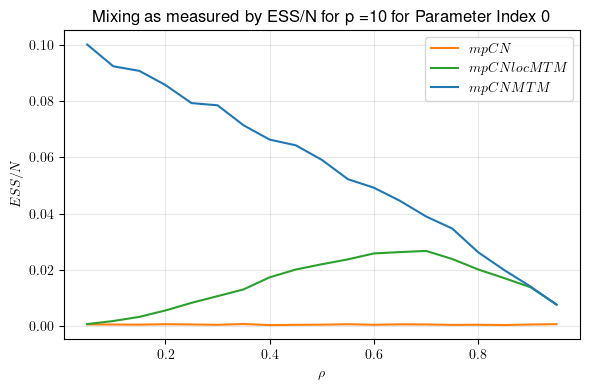

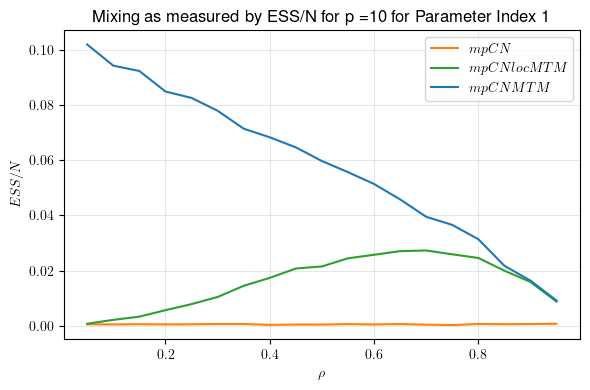

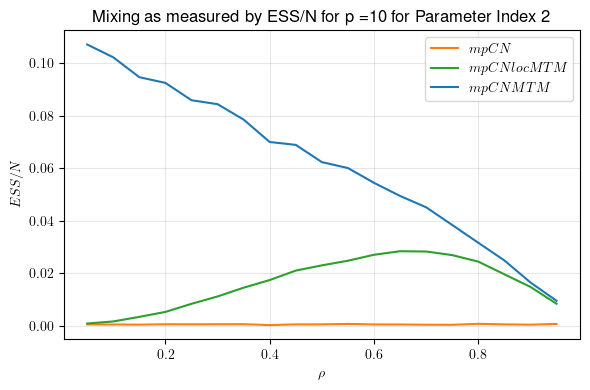

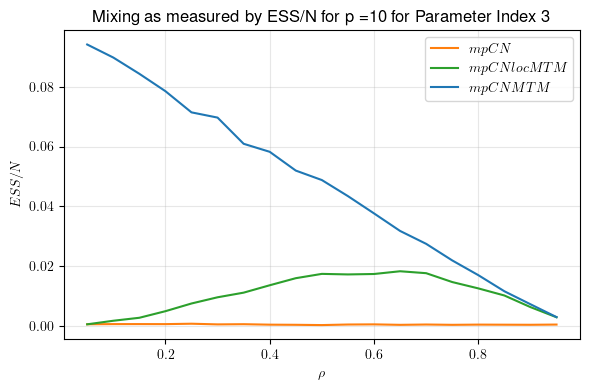

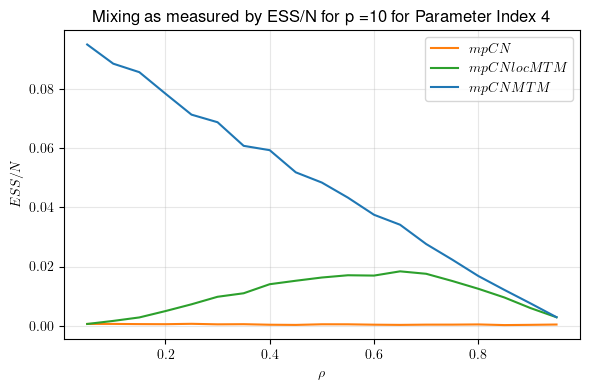

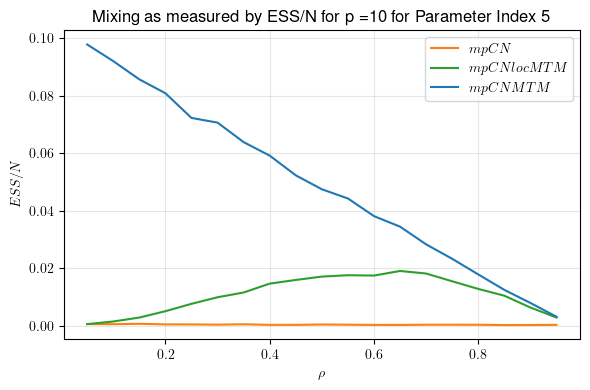

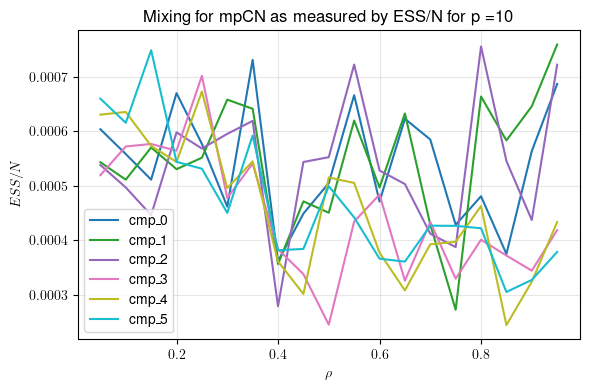

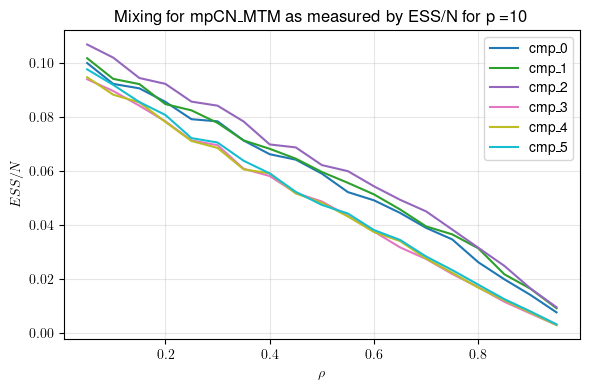

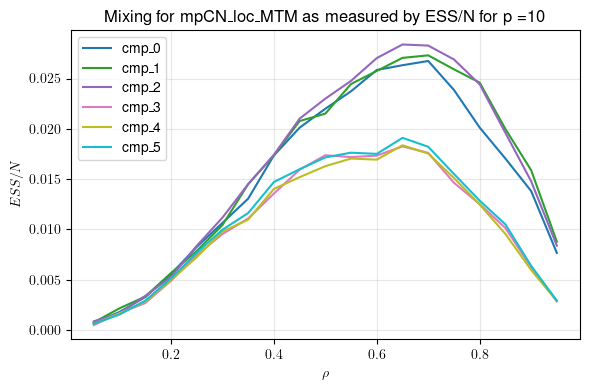

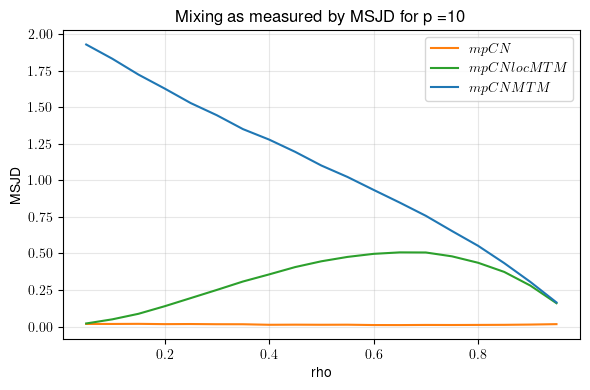

Currently running: p=100
Delta rho: 0.05
Number of Samples: 200000
# Parallel Processors Used: 11
Total MCMC Runs: 57


Parallel MCMC Runs:   0%|          | 0/57 [00:00<?, ?it/s]

Compiling Data:   0%|          | 0/19 [00:00<?, ?it/s]

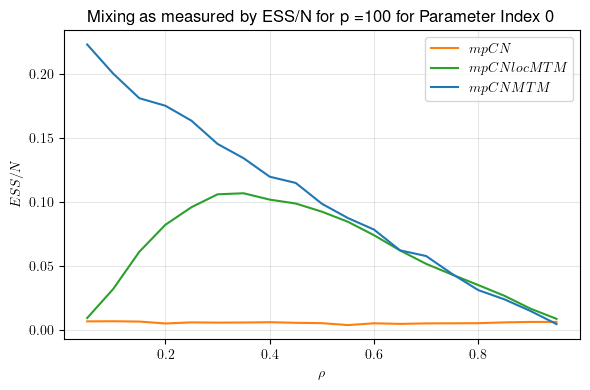

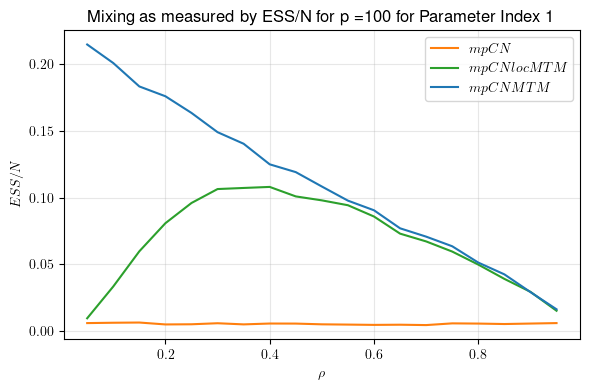

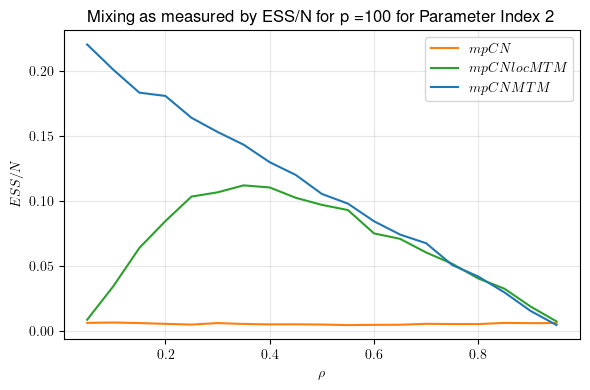

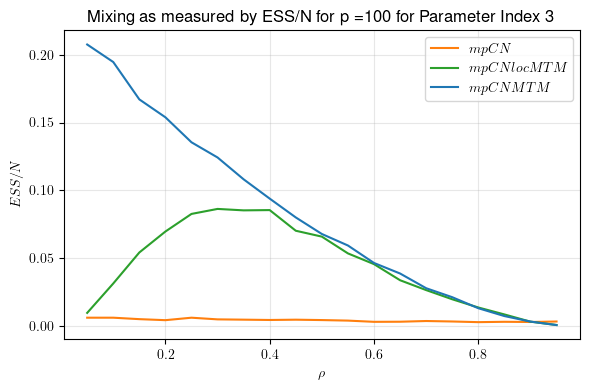

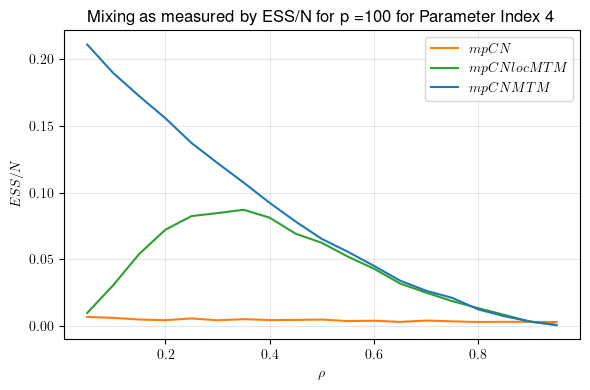

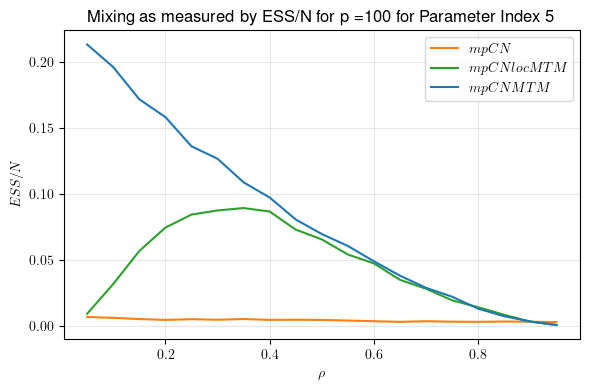

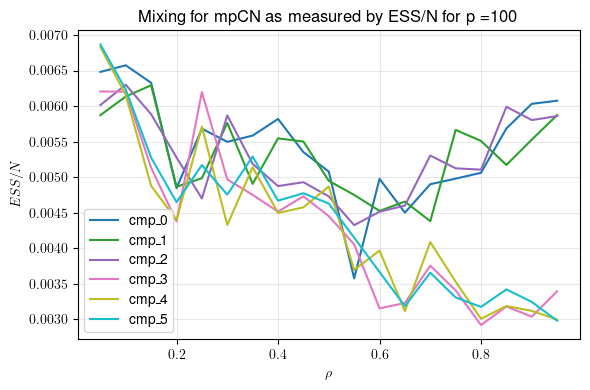

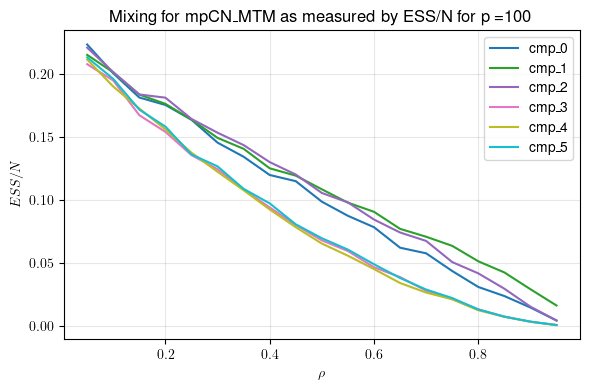

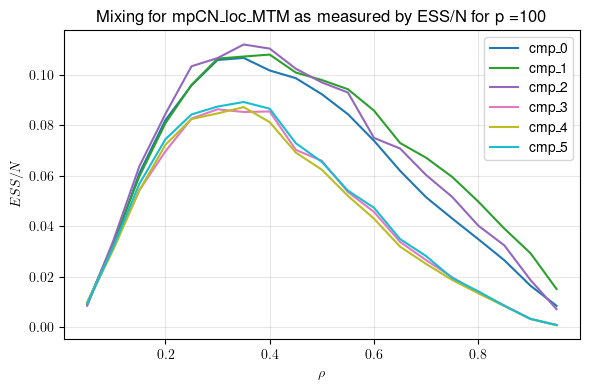

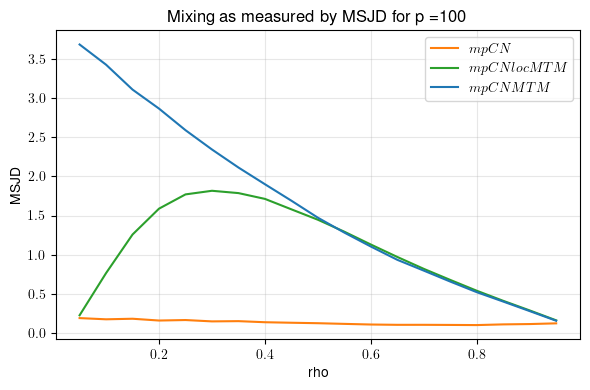

Currently running: p=1000
Delta rho: 0.05
Number of Samples: 10000
# Parallel Processors Used: 11
Total MCMC Runs: 57


Parallel MCMC Runs:   0%|          | 0/57 [00:00<?, ?it/s]

Compiling Data:   0%|          | 0/19 [00:00<?, ?it/s]

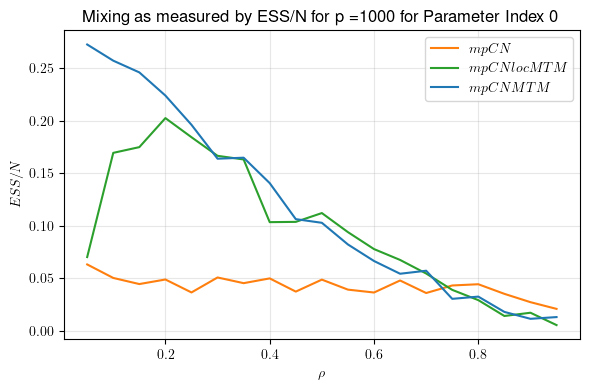

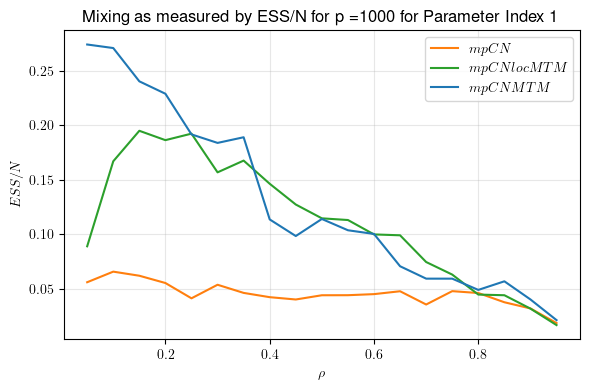

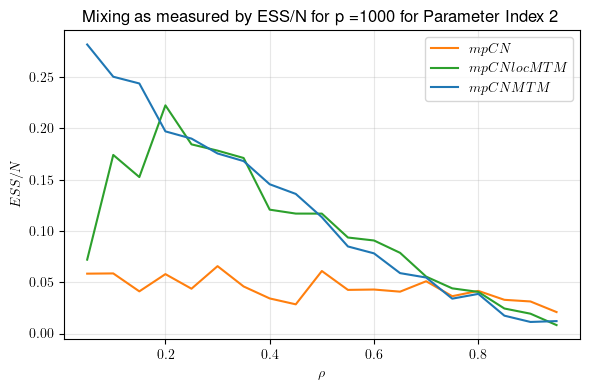

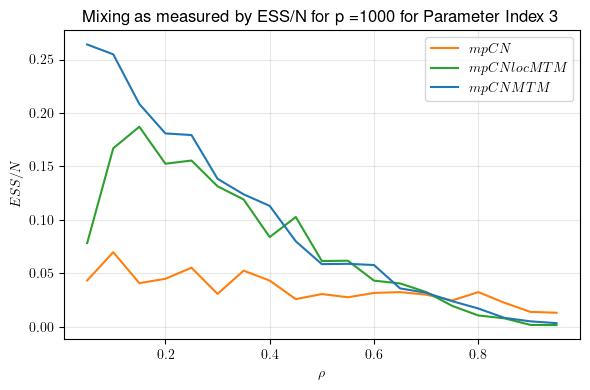

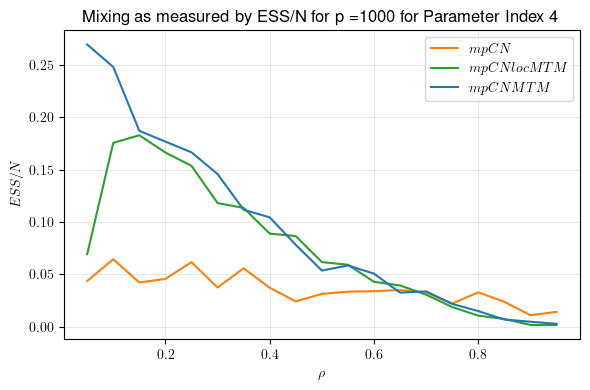

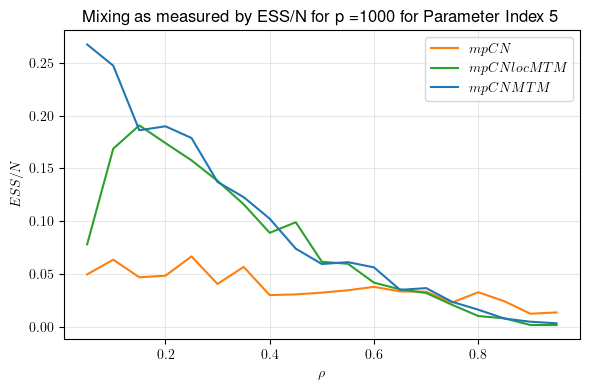

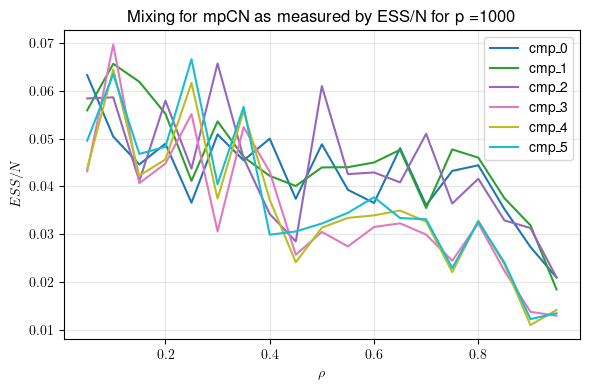

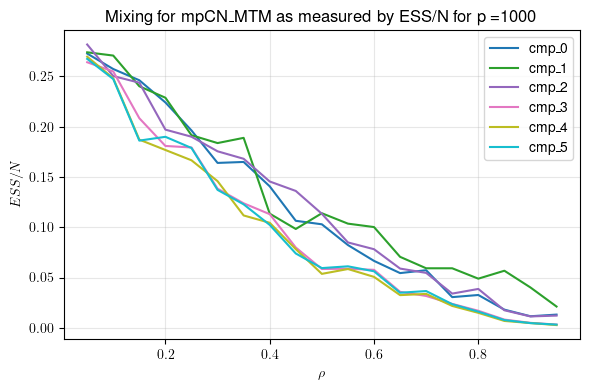

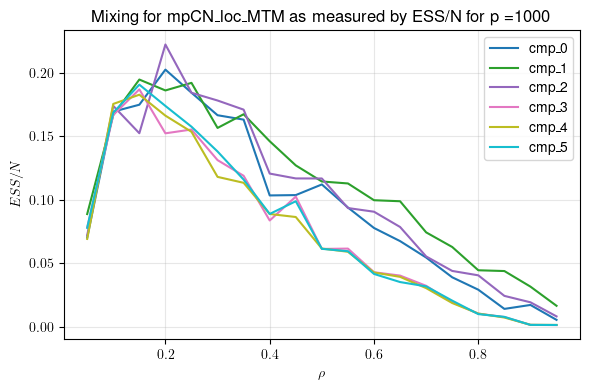

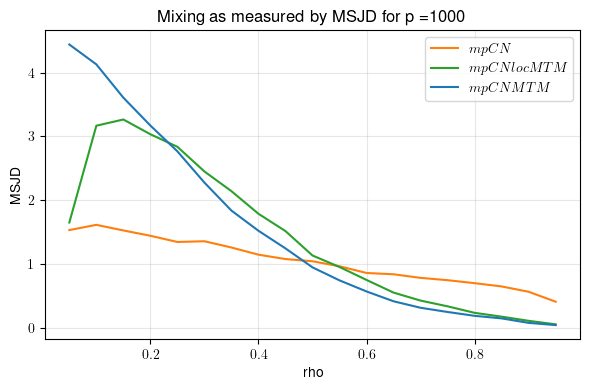

Currently running: p=10000
Delta rho: 0.05
Number of Samples: 1000
# Parallel Processors Used: 11
Total MCMC Runs: 57


Parallel MCMC Runs:   0%|          | 0/57 [00:00<?, ?it/s]

Compiling Data:   0%|          | 0/19 [00:00<?, ?it/s]

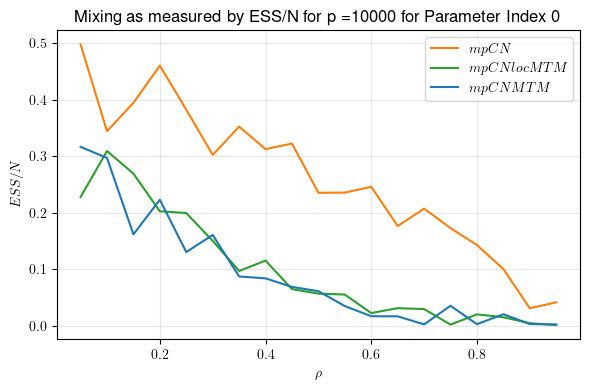

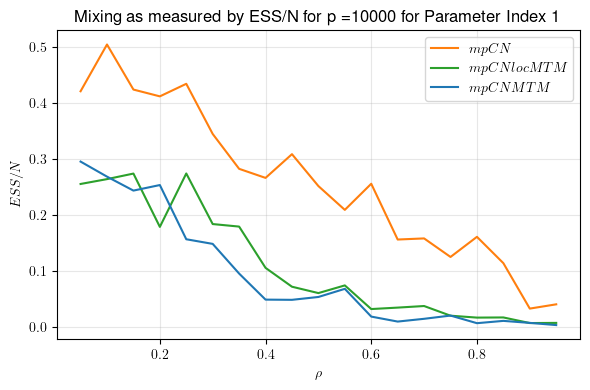

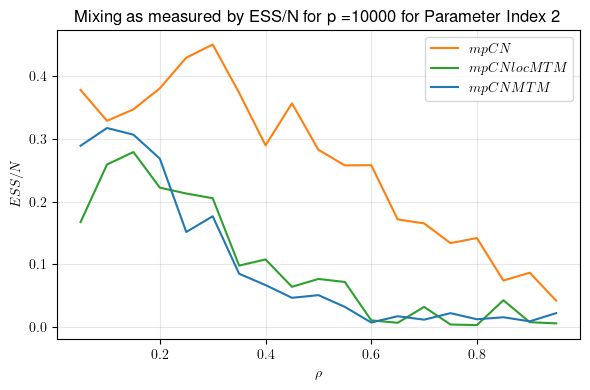

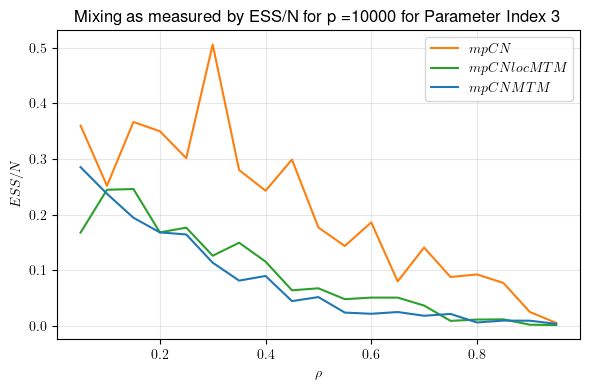

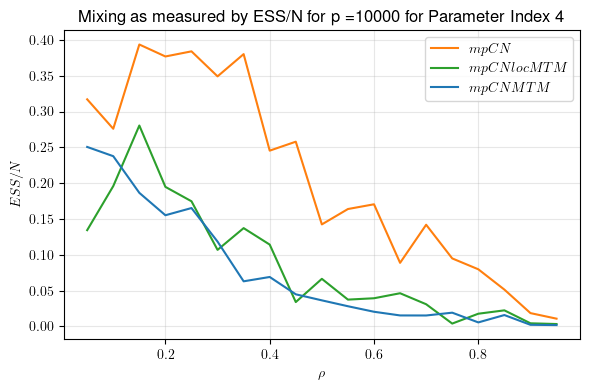

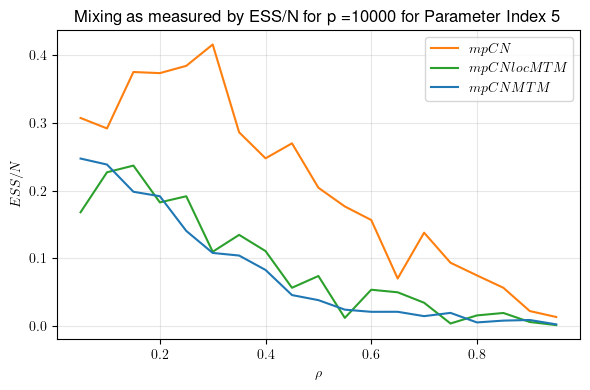

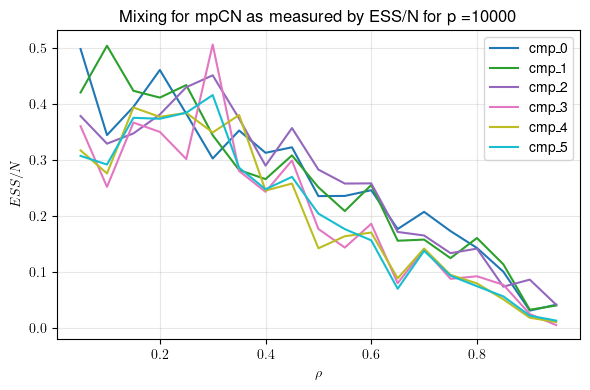

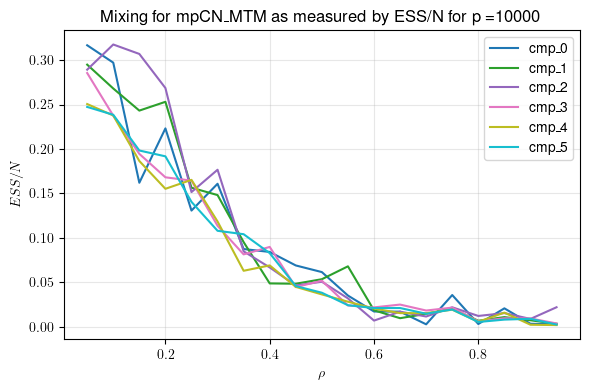

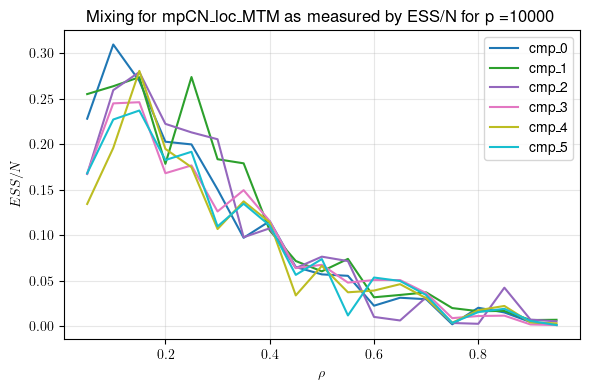

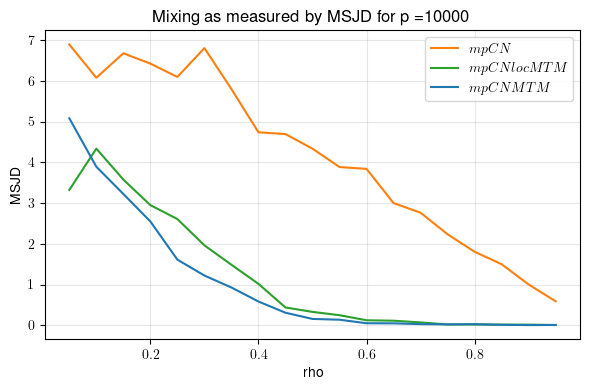

In [5]:
#Mixing as a function of rho Experiment 4

#Stiff Version of Experiment 2

ModDmEx4 = 4 #Size of the matrix
NumParmsEx4 = int(ModDmEx4 *(ModDmEx4  -1)/2)

#CovEx4 = np.array([[ 3.09615255, -0.42256446, -0.01699562, 1.52032843, 0.196684, 0.91198176],
# [-0.42256446,  0.47653539,  0.13517459, -0.15567356, -0.12246178,  0.03620587],
# [-0.01699562,  0.13517459,  0.90420916,  0.35872565,  0.0865228,   0.42293649],
# [ 1.52032843, -0.15567356,  0.35872565,  2.1249358,   0.03393446,  1.34534855],
# [ 0.196684,   -0.12246178,  0.0865228,   0.03393446,  0.90437014, -0.111162  ],
# [ 0.91198176,  0.03620587,  0.42293649,  1.34534855, -0.111162,    1.63623487]])


cov0 = 5
gam = 1.5
CovDiag = [cov0* (j**(-gam)) for j in list(range(1,NumParmsEx4+1))]
Q = MCMCsmp.rndm_orth_matrix(NumParmsEx4)
CovEx4 = Q.T@ MCMCsmp.mkDiagCov(CovDiag)@ Q


expId = 2
FileNmBase= "Data/Large_p_study/Experiment_4/Ex_ID_4_"+ str(expId)
probDataFile = FileNmBase + "Problem_Data.txt"

with open(probDataFile, 'a') as file:
    file.write("model dim: " + str(MCMCsmp.ModDmEx4) + "\n")
    file.write("gvec: " + str(MCMCsmp.gvecEx4) + "\n")
    file.write("kap: " + str(MCMCsmp.kapEx4) + "\n")
    file.write("y: " + str(MCMCsmp.yEx4) + "\n")
    file.write("sig: " + str(MCMCsmp.sigEx4)+ "\n")
    file.write("Prior Cov: \n \t" + str(CovEx4))

#Perform a warm up run
q0ad = np.zeros(NumParmsEx4)
#q0ad = np.random.normal(0,1,NumParmsEx4)

#numSmpWarm0 = 400 
numSmpWarm0 = 90000
#numSmpWarm =  500 
numSmpWarm = 100000

pWarm = 100
rhoWarm = .1
#WarmSamps = MpCNBBMTM(q0ad,NumParmsEx4,CovEx4,rhoWarm,MCMCsmp.PotEx4,pWarm,numSmpWarm +1)
WarmSamps = MpCN(q0ad,NumParmsEx4,CovEx4,rhoWarm,MCMCsmp.PotEx4,pWarm,numSmpWarm +1)
#rhoWarm = .998
#WarmSamps = MCMCsmp.locMpCNMTM(q0ad,NumParmsEx4,CovEx4,rhoWarm,MCMCsmp.PotEx4,pWarm,numSmpWarm +1,True)

#csvFileNm = FileNmBase+ "_p_" + str(pWarm)+ "_rho_" + str(rhoWarm) + "_numSamps_" + str(numSmpWarm) +"_Warm_up_DATA.csv"
#writeCSV(csvFileNm,WarmSamps)

#Idiot Check Histogram
#Dimensions For Histogram Plot
histFileNm = FileNmBase+ "_p_" + str(pWarm)+ "_rho_" + str(rhoWarm) + "_numSamps_" + str(numSmpWarm) +"_Warm_up_HIST.png"
R = 5
dr = .1
makeHistGrid(R, dr, WarmSamps, NumParmsEx4,histFileNm, True)

#Input to studies
#[p,NumRho,NumSamples]

#ImpLst = [[10,20,2500]]
#ImpLst = [[10,20,2500000]]
#ImpLst = [[10,20,100000],[100,20,100000],[1000,20,10000]]#,[10000,20,100000]]
ImpLst = [[10,20,500000],[100,20,200000],[1000,20,10000], [10000,20,1000]]
#ImpLst = [[10,20,10000],[100,20,10000],[1000,10,5000]]


for Imp in ImpLst:
    pCur = Imp[0]

    NumRho = Imp[1]
    delRho = 1/NumRho
    rho = delRho
    NumSamps = Imp[2]
    
    print("Currently running: p=" + str(pCur))
    print("Delta rho: " + str(delRho))
    print("Number of Samples: " + str(NumSamps))

    rhoLst = []
    ESSLstOG = []
    ESSLstLoc = []
    ESSLstGlob = []
    MSJDLstOG = []
    MSJDLstLoc = []
    MSJDLstGlob = []

    for parmIndx in range(0,NumParmsEx4):
        ESSLstOG.append([])
        ESSLstLoc.append([])
        ESSLstGlob.append([])

    rhoCur= rho
    for curRnInx in range(0,NumRho-1):
        rhoLst.append(rhoCur)
        rhoCur += delRho

    if __name__ == "__main__": 
        MCMCsampRun = []
        workers_used = mp.cpu_count() 
        print("# Parallel Processors Used: " +str(workers_used))
        with ProcessPoolExecutor(max_workers=workers_used) as pool:
            for rhoCur in rhoLst:
                strIndx = random.randint(numSmpWarm0, numSmpWarm)
                q0z = WarmSamps[strIndx]
                CurfNinput = (q0z,NumParmsEx4,CovEx4,rhoCur,MCMCsmp.PotEx4,pCur,NumSamps)
                MCMCsampRun.append(pool.submit(MCMCsmp.mixMetricsmPCN,*CurfNinput))
                MCMCsampRun.append(pool.submit(MCMCsmp.mixMetricsmlocPCNMTM,*CurfNinput))
                MCMCsampRun.append(pool.submit(MCMCsmp.mixMetricsBBMTM,*CurfNinput))

            print("Total MCMC Runs: " + str(len(MCMCsampRun)))
            results = [None]*len(MCMCsampRun)
            # map Future -> index so we can keep ordered results
            where = {f:i for i, f in enumerate(MCMCsampRun)}

            for f in tqdm(as_completed(MCMCsampRun), total=len(MCMCsampRun), desc="Parallel MCMC Runs"):
                i = where[f]
                results[i] = f.result()
    
    for curRnInx in tqdm(range(0,NumRho-1), desc= "Compiling Data"):
        curSampOGData = MCMCsampRun[3*curRnInx].result()
        curSampLocData = MCMCsampRun[3*curRnInx +1].result()
        curSampGlobData = MCMCsampRun[3*curRnInx +2].result()

        for parmIndx in range(0,NumParmsEx4):    
            ESSLstOG[parmIndx].append(curSampOGData[0][parmIndx])
            ESSLstLoc[parmIndx].append(curSampLocData[0][parmIndx])
            ESSLstGlob[parmIndx].append(curSampGlobData[0][parmIndx])
        
        MSJDLstOG.append(curSampOGData[1])
        MSJDLstLoc.append(curSampLocData[1])
        MSJDLstGlob.append(curSampGlobData[1])

    curRunData ="p_" + str(pCur) + "_drho_" + str(delRho) + "_NSamps_" + str(NumSamps)
    csvFileNm = FileNmBase + curRunData +  "_DATA.csv"

    writeCSV(csvFileNm,[rhoLst,ESSLstOG,ESSLstLoc,ESSLstGlob,MSJDLstOG,MSJDLstLoc,MSJDLstGlob])
    

    
    #Generate figures for ESS/N vs rho for each component of the posterior
    for parmIndx in range(0,NumParmsEx4):
        fig, ax = plt.subplots(figsize=(6, 4))

        ax.plot(rhoLst, ESSLstOG[parmIndx], linestyle="-", label=r"$mpCN$", color="tab:orange")
        ax.plot(rhoLst, ESSLstLoc[parmIndx], linestyle="-", label=r"$mpCNlocMTM$", color="tab:green")
        ax.plot(rhoLst, ESSLstGlob[parmIndx], linestyle="-",label=r"$mpCNMTM$", color="tab:blue")

        ax.set_xlabel(r"$\rho$")
        ax.set_ylabel(r"$ESS/N$")
        ax.set_title(r"Mixing as measured by ESS/N for p ="+str(pCur)+" for Parameter Index " + str(parmIndx))
        ax.grid(alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_ParaIndx_" + str(parmIndx)+ ".png")
    
    
    fig_colors = generate_colors(NumParmsEx4)
    
    #Generate figures for ESS/N comparing different components for mpCN
    fig, ax = plt.subplots(figsize=(6, 4))
    for parmIndx in range(0,NumParmsEx4):
        ax.plot(rhoLst, ESSLstOG[parmIndx], linestyle="-", label="cmp_"+str(parmIndx), color=fig_colors[parmIndx])
    
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$ESS/N$")
    ax.set_title(r"Mixing for mpCN as measured by ESS/N for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_mpCN.png")
    
    #Generate figures for ESS/N comparing different components for mpCNMTM
    fig, ax = plt.subplots(figsize=(6, 4))
    for parmIndx in range(0,NumParmsEx4):
        ax.plot(rhoLst, ESSLstGlob[parmIndx], linestyle="-", label="cmp_"+str(parmIndx), color=fig_colors[parmIndx])
    
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$ESS/N$")
    ax.set_title(r"Mixing for mpCN_MTM as measured by ESS/N for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_mpCN_MTM.png")
    
    #Generate figures for ESS/N comparing different components for mpCNMTMloc
    fig, ax = plt.subplots(figsize=(6, 4))
    for parmIndx in range(0,NumParmsEx4):
        ax.plot(rhoLst, ESSLstLoc[parmIndx], linestyle="-", label="cmp_"+str(parmIndx), color=fig_colors[parmIndx])
    
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$ESS/N$")
    ax.set_title(r"Mixing for mpCN_loc_MTM as measured by ESS/N for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_ESS_v_rho_mpCN_MTM_loc.png")


    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(rhoLst, MSJDLstOG, linestyle="-",label=r"$mpCN$", color="tab:orange")
    ax.plot(rhoLst, MSJDLstLoc, linestyle="-",label=r"$mpCNlocMTM$", color="tab:green")
    ax.plot(rhoLst, MSJDLstGlob, linestyle="-",label=r"$mpCNMTM$", color="tab:blue")

    ax.set_xlabel(r"rho")
    ax.set_ylabel(r"MSJD")
    ax.set_title(r"Mixing as measured by MSJD for p ="+str(pCur))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(FileNmBase + curRunData+ "_MSJD_v_rho.png")
    plt.show()    
    
  

In [1]:
#Mixing as a function of rho Experiment 4

#Stiff Version of Experiment 2

ModDmEx4 = 4 #Size of the matrix
NumParmsEx4 = int(ModDmEx4 *(ModDmEx4  -1)/2)

#CovEx4 = np.array([[ 3.09615255, -0.42256446, -0.01699562, 1.52032843, 0.196684, 0.91198176],
# [-0.42256446,  0.47653539,  0.13517459, -0.15567356, -0.12246178,  0.03620587],
# [-0.01699562,  0.13517459,  0.90420916,  0.35872565,  0.0865228,   0.42293649],
# [ 1.52032843, -0.15567356,  0.35872565,  2.1249358,   0.03393446,  1.34534855],
# [ 0.196684,   -0.12246178,  0.0865228,   0.03393446,  0.90437014, -0.111162  ],
# [ 0.91198176,  0.03620587,  0.42293649,  1.34534855, -0.111162,    1.63623487]])

CovDiag = [cov0* (j**(-gam)) for j in list(range(1,NumParms+1))]
Q = MCMCsmp.rndm_orth_matrix(NumParms)
CovEx4 = Q.T@ mkDiagCov(CovDiag)@ Q


#Setting up basic location for saving data
expId = 2
FileNmBase= "Data/Large_p_study/Experiment_4/Ex_ID_4_"+ str(expId)
probDataFile = FileNmBase + "Problem_Data.txt"

with open(probDataFile, 'a') as file:
    file.write("model dim: " + str(MCMCsmp.ModDmEx4) + "\n")
    file.write("gvec: " + str(MCMCsmp.gvecEx4) + "\n")
    file.write("kap: " + str(MCMCsmp.kapEx4) + "\n")
    file.write("y: " + str(MCMCsmp.yEx4) + "\n")
    file.write("sig: " + str(MCMCsmp.sigEx4)+ "\n")
    file.write("Prior Cov: \n \t" + str(CovEx4))


#Perform a warm up run
#q0ad = np.zeros(NumParmsEx4)
q0ad = np.random.normal(0,1,NumParmsEx4)

#numSmpWarm0 = 4000
numSmpWarm0 = 90000
#numSmpWarm =  5000
numSmpWarm = 100000

pWarm = 100
rhoWarm = .1
#WarmSamps = MpCNBBMTM(q0ad,NumParmsEx4,CovEx4,rhoWarm,MCMCsmp.PotEx4,pWarm,numSmpWarm +1)
WarmSamps = MpCN(q0ad,NumParmsEx4,CovEx4,rhoWarm,MCMCsmp.PotEx4,pWarm,numSmpWarm +1)
#rhoWarm = .998
#WarmSamps = MCMCsmp.locMpCNMTM(q0ad,NumParmsEx4,CovEx4,rhoWarm,MCMCsmp.PotEx4,pWarm,numSmpWarm +1,True)

#csvFileNm = FileNmBase+ "_p_" + str(pWarm)+ "_rho_" + str(rhoWarm) + "_numSamps_" + str(numSmpWarm) +"_Warm_up_DATA.csv"
#writeCSV(csvFileNm,WarmSamps)

#Idiot Check Histogram
#Dimensions For Histogram Plot
histFileNm = FileNmBase+ "_p_" + str(pWarm)+ "_rho_" + str(rhoWarm) + "_numSamps_" + str(numSmpWarm) +"_Warm_up_HIST.png"
R = 5
dr = .1
makeHistGrid(R, dr, WarmSamps, NumParmsEx4,histFileNm, True)

NameError: name 'NumParms' is not defined